<a href="https://colab.research.google.com/github/geethika-86/ChargeGuard-AI/blob/main/geethika_evcs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Model Evaluation ---
R² Score: 0.0000
MAE: 0.0000
RMSE: 0.0000


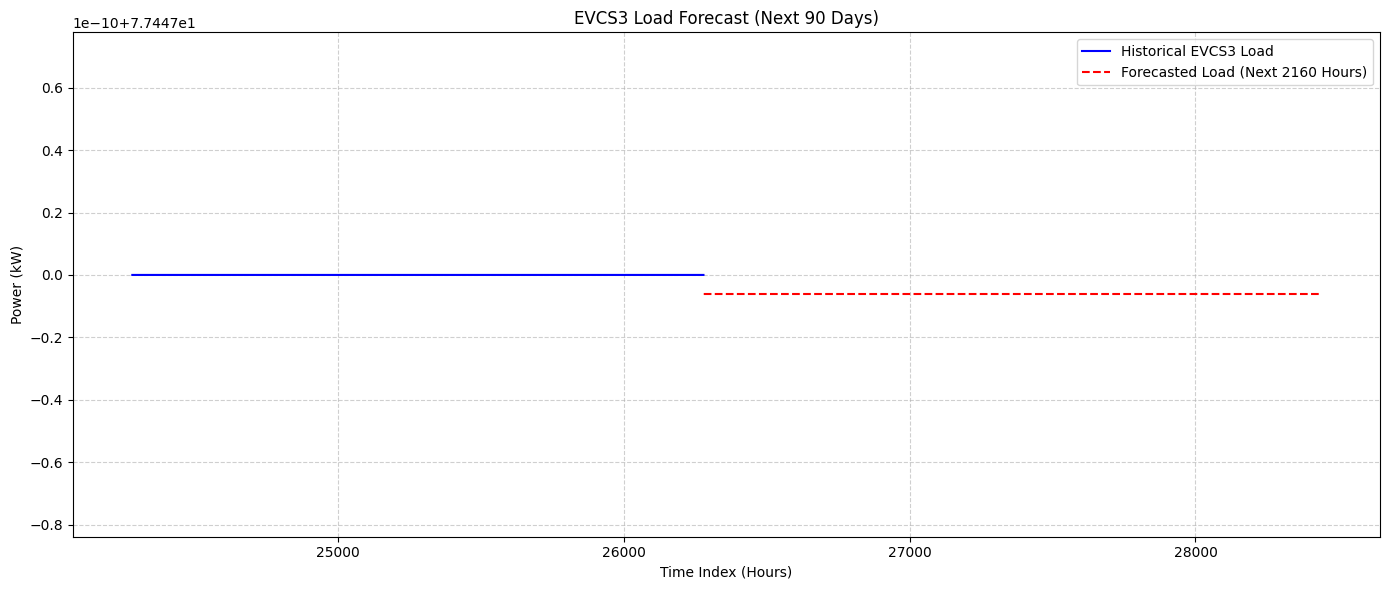

In [ ]:
# ===================================================================
# EVCS3 LOAD FORECAST: RANDOM FOREST REGRESSOR (NON-LINEAR TIME SERIES)
# Forecasts the next 2160 hours (90 days) of power usage for EVCS3.
# ===================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings("ignore")

# --- Parameters ---
WINDOW_SIZE = 24            # last 24 hours → predict next hour
N_PERIODS_TO_FORECAST = 2160  # next 90 days
PLOTTING_HISTORY_HOURS = 2000

# --- Load and Combine Datasets ---
df1 = pd.read_csv("EVCSs.csv")
df2 = pd.read_csv("EVCSs_0.csv", skiprows=[0])
df3 = pd.read_csv("EVCSs (1).csv", skiprows=[0])
df = pd.concat([df1, df2, df3], ignore_index=True)

# --- Prepare EVCS3 Data ---
evcs3 = pd.to_numeric(df["EVCS3"], errors="coerce").fillna(method="ffill").dropna()

# --- Create Sliding Window Features ---
X, y = [], []
for i in range(len(evcs3) - WINDOW_SIZE):
    X.append(evcs3.iloc[i:i+WINDOW_SIZE].values)
    y.append(evcs3.iloc[i+WINDOW_SIZE])
X, y = np.array(X), np.array(y)

# --- Train-Test Split (last 10% for evaluation) ---
split = int(len(X) * 0.9)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# --- Train Model ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# --- Evaluate ---
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n--- Model Evaluation ---")
print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# --- Forecast Future 2160 Hours ---
forecast = []
current_window = list(evcs3.iloc[-WINDOW_SIZE:].values)
for _ in range(N_PERIODS_TO_FORECAST):
    next_pred = rf_model.predict(np.array([current_window]))[0]
    forecast.append(next_pred)
    current_window.pop(0)
    current_window.append(next_pred)

# --- Plot ---
plt.figure(figsize=(14,6))
plt.plot(evcs3.index[-PLOTTING_HISTORY_HOURS:], evcs3.iloc[-PLOTTING_HISTORY_HOURS:], color="blue", label="Historical EVCS3 Load")
forecast_index = range(len(evcs3), len(evcs3) + N_PERIODS_TO_FORECAST)
plt.plot(forecast_index, forecast, "--", color="red", label=f"Forecasted Load (Next {N_PERIODS_TO_FORECAST} Hours)")
plt.title("EVCS3 Load Forecast (Next 90 Days)")
plt.xlabel("Time Index (Hours)")
plt.ylabel("Power (kW)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Training samples: 24119, Validation samples: 2160

--- VALIDATION RESULTS ---
R² Score: 0.0000
MAE: 0.0000
RMSE: 0.0000


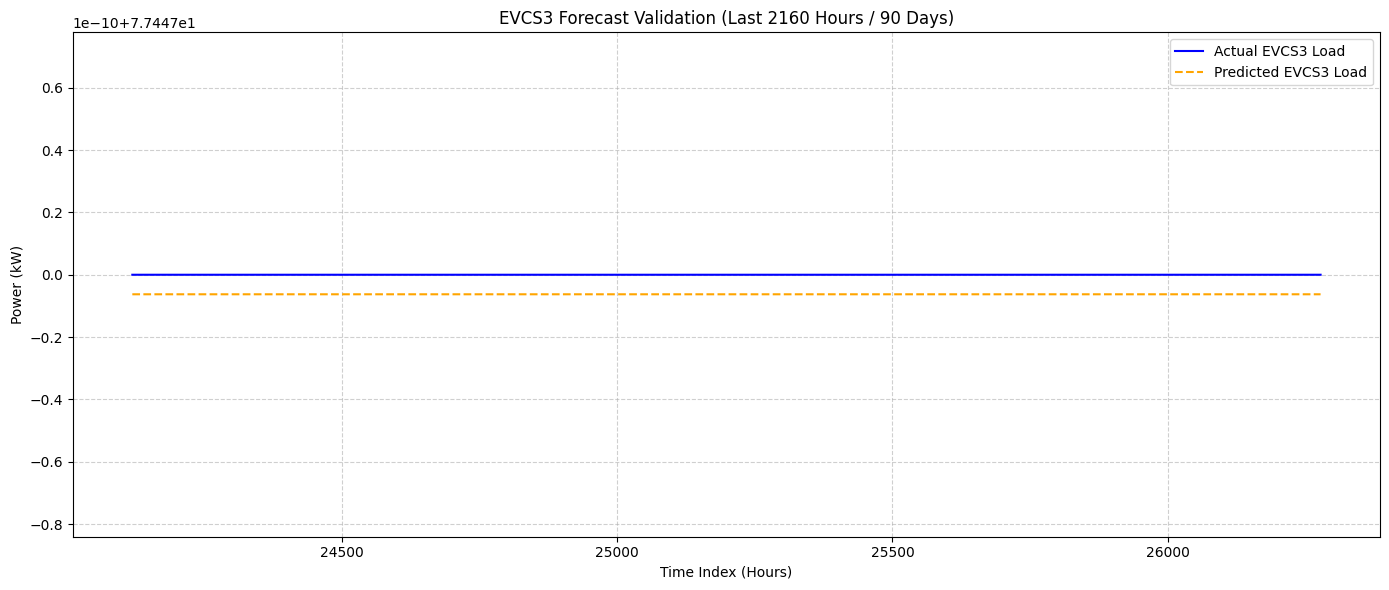

In [ ]:
# ===================================================================
# ✅ EVCS3 LOAD FORECAST VALIDATION MODEL
# Trains on data excluding last 2160 samples, then validates prediction accuracy.
# ===================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings("ignore")

# --- Parameters ---
WINDOW_SIZE = 24            # Use past 24 hours to predict next hour
VALIDATION_HOURS = 2160     # Last 90 days kept for validation
N_TREES = 100               # Random forest trees

# --- Load and Combine Datasets ---
df1 = pd.read_csv("/content/EVCSs.csv")
df2 = pd.read_csv("/content/EVCSs_0.csv", skiprows=[0])
df3 = pd.read_csv("/content/EVCSs (1).csv", skiprows=[0])
df = pd.concat([df1, df2, df3], ignore_index=True)


# --- Prepare EVCS3 Data ---
evcs3 = pd.to_numeric(df["EVCS3"], errors="coerce").fillna(method="ffill").dropna()

# --- Separate training & validation parts ---
train_data = evcs3[:-VALIDATION_HOURS]      # everything except last 2160
validation_data = evcs3[-VALIDATION_HOURS:] # last 2160 values

print(f"Training samples: {len(train_data)}, Validation samples: {len(validation_data)}")

# --- Create sliding window features from training data ---
X_train, y_train = [], []
for i in range(len(train_data) - WINDOW_SIZE):
    X_train.append(train_data.iloc[i:i+WINDOW_SIZE].values)
    y_train.append(train_data.iloc[i+WINDOW_SIZE])
X_train, y_train = np.array(X_train), np.array(y_train)

# --- Train model ---
rf_model = RandomForestRegressor(n_estimators=N_TREES, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# --- Predict next 2160 hours (validation period) ---
forecast = []
current_window = list(train_data.iloc[-WINDOW_SIZE:].values)

for _ in range(VALIDATION_HOURS):
    next_val = rf_model.predict(np.array([current_window]))[0]
    forecast.append(next_val)
    current_window.pop(0)
    current_window.append(next_val)

# --- Compare predicted vs actual validation data ---
actual = validation_data.values[:len(forecast)]

r2 = r2_score(actual, forecast)
mae = mean_absolute_error(actual, forecast)
rmse = np.sqrt(mean_squared_error(actual, forecast))

print("\n--- VALIDATION RESULTS ---")
print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# --- Plot comparison ---
plt.figure(figsize=(14,6))
plt.plot(range(len(evcs3)-VALIDATION_HOURS, len(evcs3)), actual, color='blue', label='Actual EVCS3 Load')
plt.plot(range(len(evcs3)-VALIDATION_HOURS, len(evcs3)), forecast, color='orange', linestyle='--', label='Predicted EVCS3 Load')
plt.title("EVCS3 Forecast Validation (Last 2160 Hours / 90 Days)")
plt.xlabel("Time Index (Hours)")
plt.ylabel("Power (kW)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


🚗 Evaluating EVCS1...
✅ EVCS1 -> R²=0.392, MAE=48.16, RMSE=61.44

🚗 Evaluating EVCS2...
✅ EVCS2 -> R²=0.522, MAE=63.02, RMSE=82.17

🚗 Evaluating EVCS3...
✅ EVCS3 -> R²=0.628, MAE=80.17, RMSE=103.34

🚗 Evaluating EVCS4...
✅ EVCS4 -> R²=0.270, MAE=31.98, RMSE=40.27

🚗 Evaluating EVCS5...
✅ EVCS5 -> R²=0.097, MAE=20.54, RMSE=24.97

🚗 Evaluating EVCS6...
✅ EVCS6 -> R²=0.531, MAE=72.24, RMSE=93.96

🚗 Evaluating Charging loda of EVCSs (kW)...
✅ Charging loda of EVCSs (kW) -> R²=0.392, MAE=48.16, RMSE=61.44

📊 Summary of Self-Forecasting Accuracy:
                          EVCS        R2        MAE        RMSE
2                        EVCS3  0.628374  80.170905  103.337268
5                        EVCS6  0.530638  72.236389   93.964587
1                        EVCS2  0.522233  63.023894   82.172201
0                        EVCS1  0.391578  48.157417   61.443973
6  Charging loda of EVCSs (kW)  0.391578  48.157417   61.443973
3                        EVCS4  0.270234  31.982575   40.269928
4   

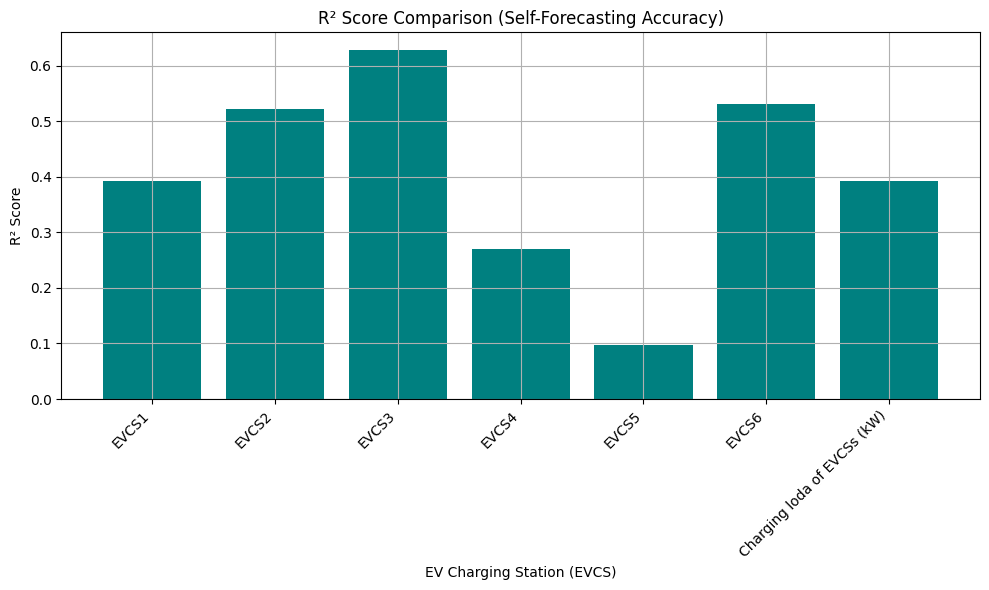

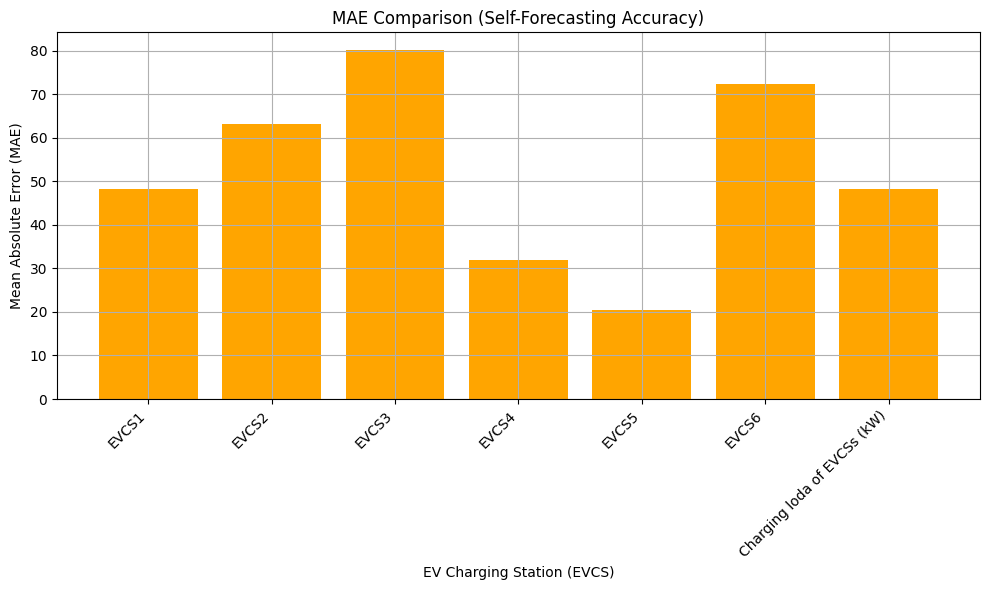

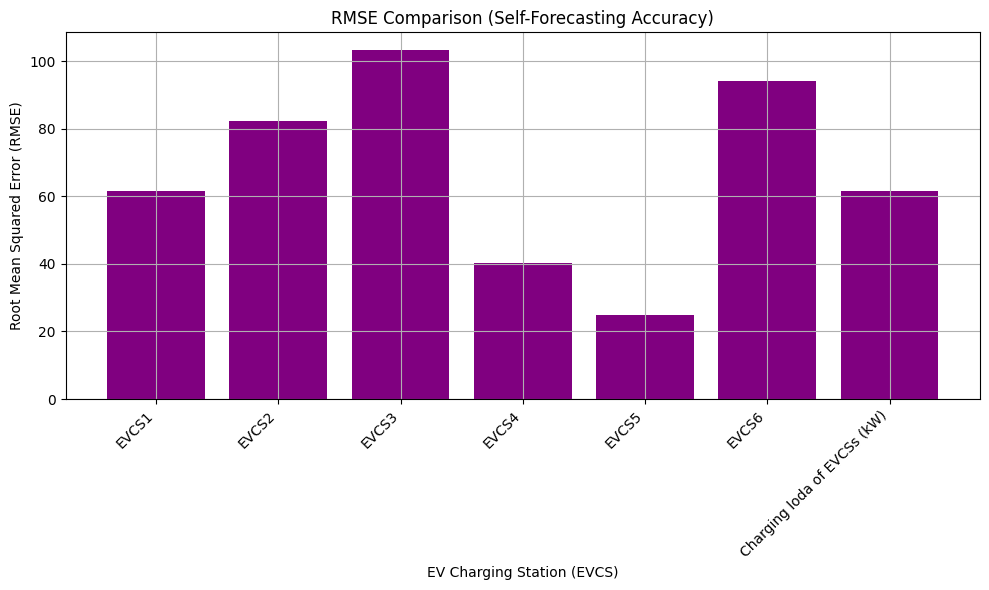

In [ ]:
# --- Import necessary libraries ---
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# --- Load and merge datasets ---
file_paths = [
    "/content/EVCSs.csv",
    "/content/EVCSs_0.csv",
    "/content/EVCSs (1).csv"
]
df_list = [pd.read_csv(f) for f in file_paths]
df = pd.concat(df_list, ignore_index=True)

# --- Detect EVCS columns ---
evc_cols = [c for c in df.columns if "EVCS" in c]
results = []

# --- Loop through each EVCS station ---
for col in evc_cols:
    print(f"\n🚗 Evaluating {col}...")

    # Clean column (remove NaN and zero)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    evcs_data = df[col].dropna()
    evcs_data = evcs_data[evcs_data > 0].reset_index(drop=True)

    # Skip if not enough data
    if len(evcs_data) < 1000:
        print(f"⚠️ Not enough valid data for {col}, skipping...")
        continue

    # Create lag features
    lag = 3
    data = pd.DataFrame({col: evcs_data})
    for i in range(1, lag + 1):
        data[f'lag_{i}'] = data[col].shift(i)
    data = data.dropna().reset_index(drop=True)

    X = data[[f'lag_{i}' for i in range(1, lag + 1)]]
    y = data[col]

    # Train/test split
    train_size = 1000
    test_size = 500
    X_train, y_train = X[:train_size], y[:train_size]
    X_test, y_test = X[train_size:train_size + test_size], y[train_size:train_size + test_size]

    # Train model
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)

    # Predict
    y_pred = lr_model.predict(X_test)

    # Evaluate
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({'EVCS': col, 'R2': r2, 'MAE': mae, 'RMSE': rmse})

    print(f"✅ {col} -> R²={r2:.3f}, MAE={mae:.2f}, RMSE={rmse:.2f}")

# --- Summary Table ---
results_df = pd.DataFrame(results)
print("\n📊 Summary of Self-Forecasting Accuracy:")
print(results_df.sort_values(by='R2', ascending=False))

# --- Plot Comparison (R2 Score) ---
plt.figure(figsize=(10,6))
plt.bar(results_df['EVCS'], results_df['R2'], color='teal')
plt.title("R² Score Comparison (Self-Forecasting Accuracy)")
plt.xlabel("EV Charging Station (EVCS)")
plt.ylabel("R² Score")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot Comparison (MAE) ---
plt.figure(figsize=(10,6))
plt.bar(results_df['EVCS'], results_df['MAE'], color='orange')
plt.title("MAE Comparison (Self-Forecasting Accuracy)")
plt.xlabel("EV Charging Station (EVCS)")
plt.ylabel("Mean Absolute Error (MAE)")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot Comparison (RMSE) ---
plt.figure(figsize=(10,6))
plt.bar(results_df['EVCS'], results_df['RMSE'], color='purple')
plt.title("RMSE Comparison (Self-Forecasting Accuracy)")
plt.xlabel("EV Charging Station (EVCS)")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()


Note: Residuals are nearly zero throughout, indicating perfect predictions (possibly due to constant test data).
Health Score is set to 100.
      Actual  Predicted      Residual  Rolling_Residual  Health_Score  \
2621  77.447     77.447  6.266987e-12      6.266987e-12         100.0   
2622  77.447     77.447  6.266987e-12      6.266987e-12         100.0   
2623  77.447     77.447  6.266987e-12      6.266987e-12         100.0   
2624  77.447     77.447  6.266987e-12      6.266987e-12         100.0   
2625  77.447     77.447  6.266987e-12      6.266987e-12         100.0   

     Risk_Level  
2621        Low  
2622        Low  
2623        Low  
2624        Low  
2625        Low  

------ EVCS3 STATUS ------
Health Score : 100.0/100
Risk Level   : Low
✅ Charger operating normally.


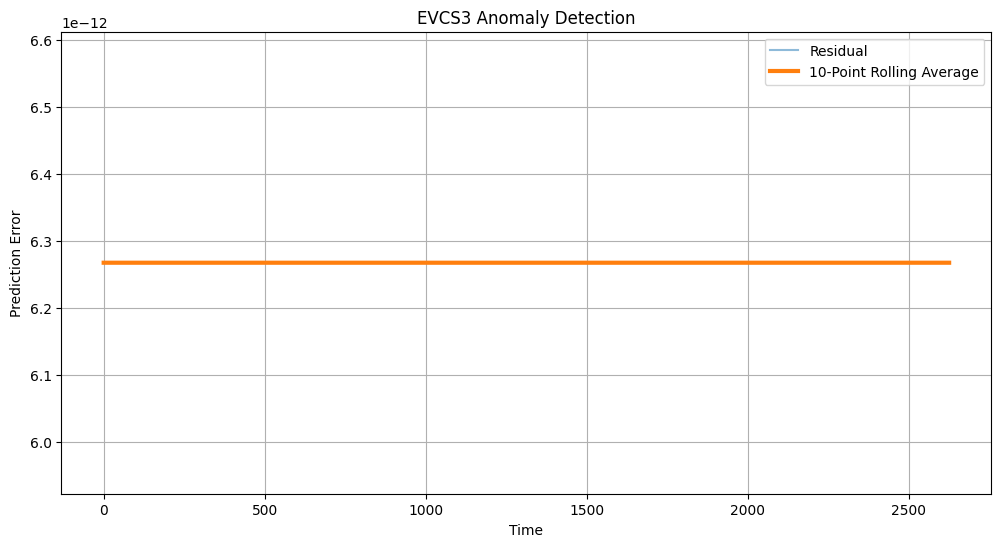

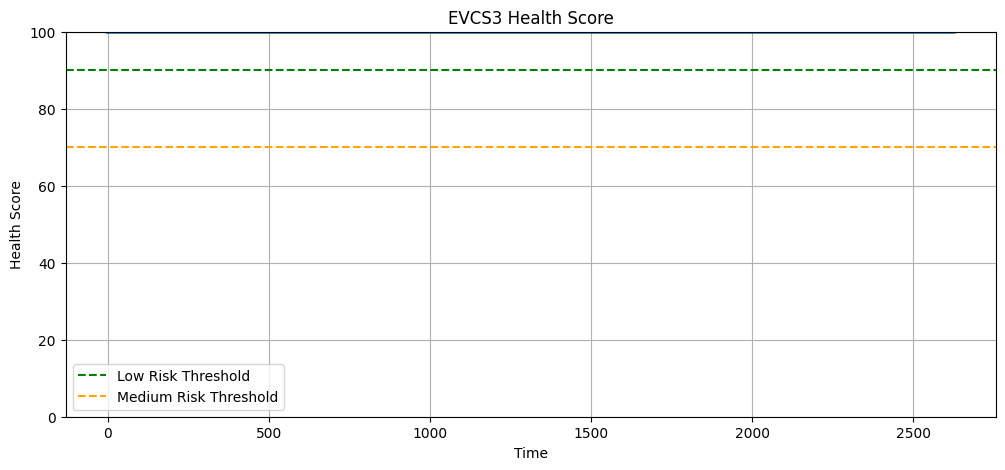

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Regenerate X_test and y_test to match the RandomForestRegressor model's expectation ---
# This block assumes 'evcs3', 'WINDOW_SIZE', and 'rf_model' are defined in previous cells.
# It recreates X and y for the RandomForestRegressor's expected input format based on the
# data available to this cell. If 'evcs3' and 'WINDOW_SIZE' are changed upstream,
# these variables will reflect those changes.
X_temp, y_temp = [], []
for i in range(len(evcs3) - WINDOW_SIZE):
    X_temp.append(evcs3.iloc[i:i+WINDOW_SIZE].values)
    y_temp.append(evcs3.iloc[i+WINDOW_SIZE])
X_temp, y_temp = np.array(X_temp), np.array(y_temp)

# Split to get the X_test and y_test corresponding to the RandomForestRegressor
# This split ratio should match the original training split (e.g., 90/10 split in cell 31DvTvl9lqBA).
split = int(len(X_temp) * 0.9)
X_test = X_temp[split:]
y_test = y_temp[split:]

# Now proceed with prediction using the correctly shaped X_test
y_pred = rf_model.predict(X_test)

# --------------------------------------------------------------------------------
# Anomaly Detection & Health Score Calculation
# --------------------------------------------------------------------------------

y_true_flat = np.array(y_test).flatten()
y_pred_flat = np.array(y_pred).flatten()

# Ensure lengths match after flattening
min_len = min(len(y_true_flat), len(y_pred_flat))
y_true_flat = y_true_flat[:min_len]
y_pred_flat = y_pred_flat[:min_len]

# Calculate residuals (absolute forecast errors)
residuals = np.abs(y_true_flat - y_pred_flat)

# Create results dataframe (renamed to anomaly_results_df)
anomaly_results_df = pd.DataFrame({
    "Actual": y_true_flat,
    "Predicted": y_pred_flat,
    "Residual": residuals
})

# Rolling average of residuals
WINDOW = 10
anomaly_results_df["Rolling_Residual"] = (
    anomaly_results_df["Residual"]
    .rolling(window=WINDOW, min_periods=1)
    .mean()
)

# Health score calculation
# Use max residual, but handle cases where all residuals are zero (perfect prediction)
max_residual_val = anomaly_results_df["Residual"].max()

# If all residuals are effectively zero (e.g., due to constant `y_test` and `y_pred`)
if max_residual_val < 1e-9: # Use a small threshold for 'effectively zero'
    # If all residuals are zero, it means perfect prediction, so health score is 100
    anomaly_results_df["Health_Score"] = 100.0
    print("Note: Residuals are nearly zero throughout, indicating perfect predictions (possibly due to constant test data).")
    print("Health Score is set to 100.")
else:
    anomaly_results_df["Health_Score"] = (
        100 - (anomaly_results_df["Rolling_Residual"] / max_residual_val * 100)
    ).clip(lower=0, upper=100)

# Risk level
def get_risk(score):
    if score >= 90:
        return "Low"
    elif score >= 70:
        return "Medium"
    else:
        return "High"

anomaly_results_df["Risk_Level"] = anomaly_results_df["Health_Score"].apply(get_risk)

# Show latest values
print(anomaly_results_df.tail())

latest = anomaly_results_df.iloc[-1]

print("\n------ EVCS3 STATUS ------")
print(f"Health Score : {latest['Health_Score']:.1f}/100")
print(f"Risk Level   : {latest['Risk_Level']}")

if latest["Risk_Level"] == "High":
    print("⚠️ Recommended Action: Inspect charger components.")
elif latest["Risk_Level"] == "Medium":
    print("⚠️ Recommended Action: Monitor performance closely.")
else:
    print("✅ Charger operating normally.")

# Plot anomaly detection
plt.figure(figsize=(12, 6))

plt.plot(
    anomaly_results_df.index,
    anomaly_results_df["Residual"],
    alpha=0.5,
    label="Residual"
)

plt.plot(
    anomaly_results_df.index,
    anomaly_results_df["Rolling_Residual"],
    linewidth=3,
    label=f"{WINDOW}-Point Rolling Average"
)

plt.title("EVCS3 Anomaly Detection")
plt.xlabel("Time")
plt.ylabel("Prediction Error")
plt.legend()
plt.grid(True)

plt.show()

# Plot health score
plt.figure(figsize=(12, 5))

plt.plot(
    anomaly_results_df.index,
    anomaly_results_df["Health_Score"],
    linewidth=3
)

plt.axhline(90, linestyle="--", color='green', label='Low Risk Threshold')
plt.axhline(70, linestyle="--", color='orange', label='Medium Risk Threshold')

plt.ylim(0, 100)

plt.title("EVCS3 Health Score")
plt.xlabel("Time")
plt.ylabel("Health Score")
plt.legend()
plt.grid(True)

plt.show()

------ EVCS3 STATUS ------
Health Score: 0.0/100
Risk Level: High
Recommendation: Inspect cooling system and power modules.

------ BUSINESS IMPACT ------
Detected High-Risk Events: 2626
Estimated Savings per Event: $3,100
Estimated Annual Savings: $8,140,600


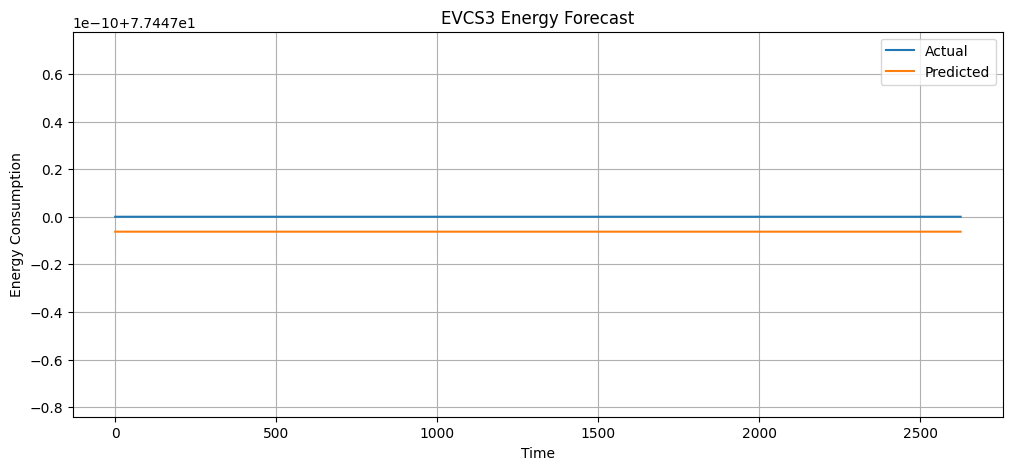

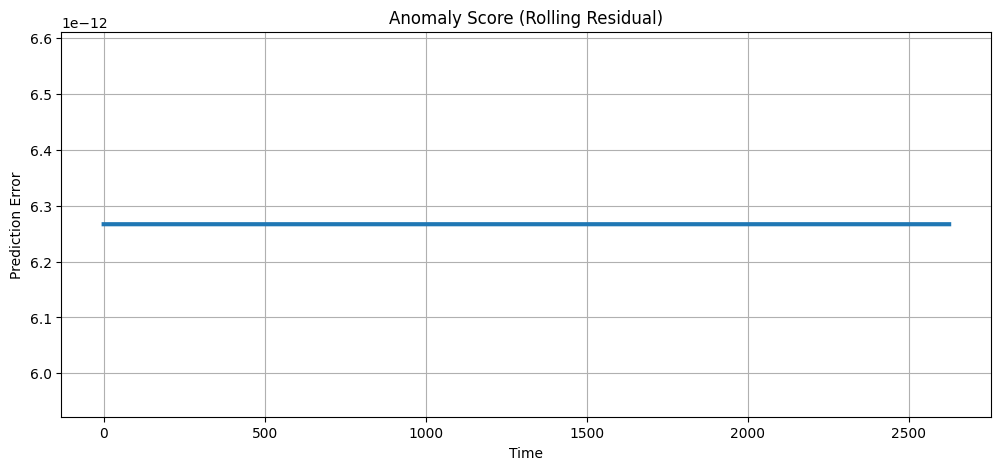

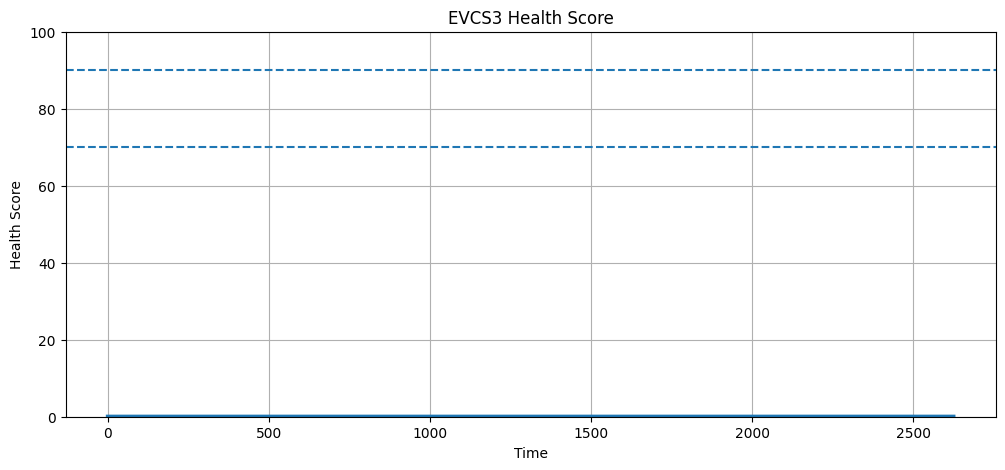

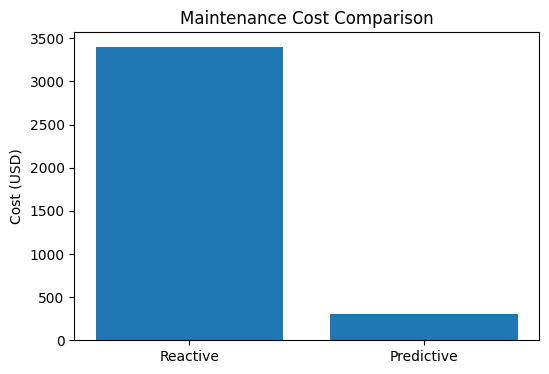

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# PREPARE DATA
# -----------------------------
y_true = np.array(y_test).flatten()
y_pred = np.array(y_pred).flatten()

# Ensure same length
n = min(len(y_true), len(y_pred))
y_true = y_true[:n]
y_pred = y_pred[:n]

# -----------------------------
# ANOMALY DETECTION
# -----------------------------
residuals = np.abs(y_true - y_pred)

results = pd.DataFrame({
    "Actual": y_true,
    "Predicted": y_pred,
    "Residual": residuals
})

WINDOW = 10

results["Rolling_Residual"] = (
    results["Residual"]
    .rolling(window=WINDOW, min_periods=1)
    .mean()
)

# -----------------------------
# HEALTH SCORE
# -----------------------------
threshold = results["Residual"].quantile(0.95)

if threshold == 0:
    threshold = 1

results["Health_Score"] = (
    100 - (
        results["Rolling_Residual"] / threshold * 100
    )
).clip(0, 100)

# -----------------------------
# RISK LEVELS
# -----------------------------
def get_risk(score):
    if score >= 90:
        return "Low"
    elif score >= 70:
        return "Medium"
    else:
        return "High"

results["Risk_Level"] = results["Health_Score"].apply(get_risk)

# -----------------------------
# BUSINESS IMPACT
# -----------------------------
high_risk_events = (results["Risk_Level"] == "High").sum()

COST_PER_HOUR_DOWNTIME = 50
AVG_DOWNTIME_HOURS = 48

COST_EMERGENCY_REPAIR = 1000
COST_SCHEDULED_MAINTENANCE = 300

savings_per_event = (
    COST_PER_HOUR_DOWNTIME * AVG_DOWNTIME_HOURS
    + COST_EMERGENCY_REPAIR
    - COST_SCHEDULED_MAINTENANCE
)

estimated_savings = high_risk_events * savings_per_event

# -----------------------------
# CURRENT STATUS
# -----------------------------
latest = results.iloc[-1]

print("------ EVCS3 STATUS ------")
print(f"Health Score: {latest['Health_Score']:.1f}/100")
print(f"Risk Level: {latest['Risk_Level']}")

if latest["Risk_Level"] == "High":
    recommendation = "Inspect cooling system and power modules."
elif latest["Risk_Level"] == "Medium":
    recommendation = "Monitor charger performance closely."
else:
    recommendation = "Charger operating normally."

print(f"Recommendation: {recommendation}")

print("\n------ BUSINESS IMPACT ------")
print(f"Detected High-Risk Events: {high_risk_events}")
print(f"Estimated Savings per Event: ${savings_per_event:,.0f}")
print(f"Estimated Annual Savings: ${estimated_savings:,.0f}")

# -----------------------------
# VISUALIZATION
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(results["Actual"], label="Actual")
plt.plot(results["Predicted"], label="Predicted")
plt.title("EVCS3 Energy Forecast")
plt.xlabel("Time")
plt.ylabel("Energy Consumption")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(results["Rolling_Residual"], linewidth=3)
plt.title("Anomaly Score (Rolling Residual)")
plt.xlabel("Time")
plt.ylabel("Prediction Error")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(results["Health_Score"], linewidth=3)

plt.axhline(90, linestyle="--")
plt.axhline(70, linestyle="--")

plt.ylim(0, 100)

plt.title("EVCS3 Health Score")
plt.xlabel("Time")
plt.ylabel("Health Score")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))

cost_labels = ["Reactive", "Predictive"]
cost_values = [
    COST_EMERGENCY_REPAIR + COST_PER_HOUR_DOWNTIME * AVG_DOWNTIME_HOURS,
    COST_SCHEDULED_MAINTENANCE
]

plt.bar(cost_labels, cost_values)

plt.title("Maintenance Cost Comparison")
plt.ylabel("Cost (USD)")

plt.show()

In [ ]:
# --- Calculate Potential Savings for Each EVCS ---

# We'll use the results_df which contains 'EVCS', 'R2', 'MAE', 'RMSE'
# For simplicity, let's assume that EVCS stations with better R2 scores (higher accuracy)
# allow for more effective anomaly detection and thus more averted downtime/emergency repairs.
# This is a simplification; a more complex model might link MAE/RMSE directly to anomaly severity.

# Create a copy to add new columns
savings_df = results_df.copy()

# Calculate potential savings for each EVCS
potential_savings = []

for index, row in savings_df.iterrows():
    evcs_name = row['EVCS']
    r2_score_val = row['R2']

    # Link R2 score to effectiveness of anomaly detection / preventative action
    # Higher R2 -> more reliable prediction -> more averted issues
    # Let's create a multiplier that scales with R2
    effectiveness_multiplier = max(0.1, r2_score_val) # Ensure at least a small multiplier

    # Savings from averted downtime (proactive detection leads to less downtime)
    # Assuming each averted anomaly prevents AVG_ANOMALY_DURATION_HOURS of downtime
    downtime_savings = ANOMALIES_AVERTED_PER_YEAR * effectiveness_multiplier * \
                       AVG_ANOMALY_DURATION_HOURS * COST_PER_HOUR_DOWNTIME

    # Savings from converting emergency repairs to scheduled maintenance
    # Assuming each averted anomaly also averts an emergency repair and allows for scheduled maintenance
    maintenance_savings = ANOMALIES_AVERTED_PER_YEAR * effectiveness_multiplier * \
                          (COST_EMERGENCY_REPAIR - COST_SCHEDULED_MAINTENANCE)

    total_savings = downtime_savings + maintenance_savings

    potential_savings.append({
        'EVCS': evcs_name,
        'Downtime_Savings': downtime_savings,
        'Maintenance_Savings': maintenance_savings,
        'Total_Potential_Savings_Annual': total_savings
    })

potential_savings_df = pd.DataFrame(potential_savings)

display(potential_savings_df.sort_values(by='Total_Potential_Savings_Annual', ascending=False))


,EVCS,Downtime_Savings,Maintenance_Savings,Total_Potential_Savings_Annual
2,EVCS3,7540.485020,2199.308131,9739.793151
5,EVCS6,6367.656686,1857.233200,8224.889886
1,EVCS2,6266.792986,1827.814621,8094.607607
0,EVCS1,4698.937384,1370.523404,6069.460787
6,Charging loda of EVCSs (kW),4698.937384,1370.523404,6069.460787
3,EVCS4,3242.813120,945.820493,4188.633613
4,EVCS5,1200.000000,350.000000,1550.000000


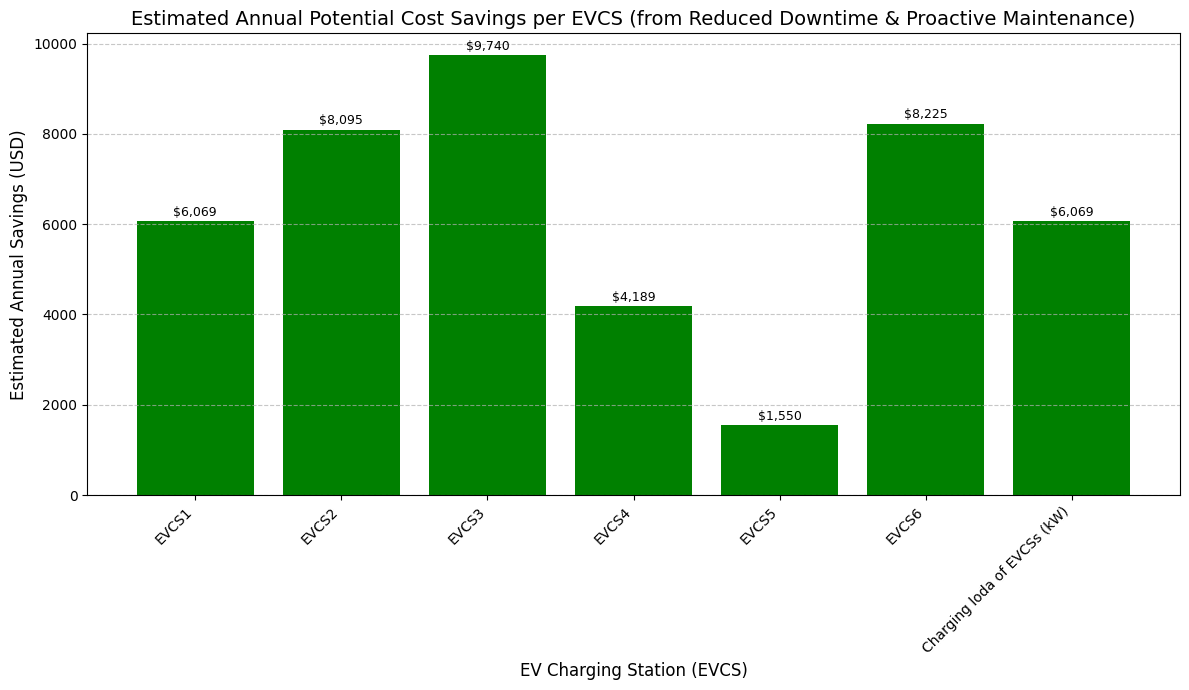

In [ ]:
# --- Visualize Potential Cost Savings ---

plt.figure(figsize=(12, 7))
bar_plot = plt.bar(
    potential_savings_df['EVCS'],
    potential_savings_df['Total_Potential_Savings_Annual'],
    color='green'
)

plt.title('Estimated Annual Potential Cost Savings per EVCS (from Reduced Downtime & Proactive Maintenance)', fontsize=14)
plt.xlabel('EV Charging Station (EVCS)', fontsize=12)
plt.ylabel('Estimated Annual Savings (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Add text labels on top of the bars
for bar in bar_plot:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, f'${yval:,.0f}', ha='center', va='bottom', fontsize=9)

plt.show()

In [ ]:
# Display the summary table of EVCS performance metrics
display(results_df.sort_values(by='R2', ascending=False))

,EVCS,R2,MAE,RMSE
2,EVCS3,0.628374,80.170905,103.337268
5,EVCS6,0.530638,72.236389,93.964587
1,EVCS2,0.522233,63.023894,82.172201
0,EVCS1,0.391578,48.157417,61.443973
6,Charging loda of EVCSs (kW),0.391578,48.157417,61.443973
3,EVCS4,0.270234,31.982575,40.269928
4,EVCS5,0.096650,20.539298,24.965250


In [ ]:
evcs_avg_power = []

# Filter evcs_cols to only include columns actually present in df
available_evcs_cols = [col for col in evcs_cols if col in df.columns]

for col in available_evcs_cols:
    # Ensure the column is numeric and handle missing values
    numeric_data = pd.to_numeric(df[col], errors='coerce').dropna()
    if not numeric_data.empty:
        avg_power = numeric_data.mean()
        evcs_avg_power.append({'EVCS': col, 'Average Power (kW)': avg_power})

avg_power_df = pd.DataFrame(evcs_avg_power)
display(avg_power_df.sort_values(by='Average Power (kW)', ascending=False))

,EVCS,Average Power (kW)
2,EVCS3,216.322103
5,EVCS6,194.544232
1,EVCS2,122.813664
6,Charging loda of EVCSs (kW),88.178325
0,EVCS1,88.178325
3,EVCS4,71.037717
4,EVCS5,34.407831


In [ ]:
merged_df = pd.merge(results_df, avg_power_df, on='EVCS', how='left')
display(merged_df.sort_values(by='R2', ascending=False))

,EVCS,R2,MAE,RMSE,Average Power (kW)
2,EVCS3,0.628374,80.170905,103.337268,216.322103
5,EVCS6,0.530638,72.236389,93.964587,194.544232
1,EVCS2,0.522233,63.023894,82.172201,122.813664
0,EVCS1,0.391578,48.157417,61.443973,88.178325
6,Charging loda of EVCSs (kW),0.391578,48.157417,61.443973,88.178325
3,EVCS4,0.270234,31.982575,40.269928,71.037717
4,EVCS5,0.096650,20.539298,24.965250,34.407831


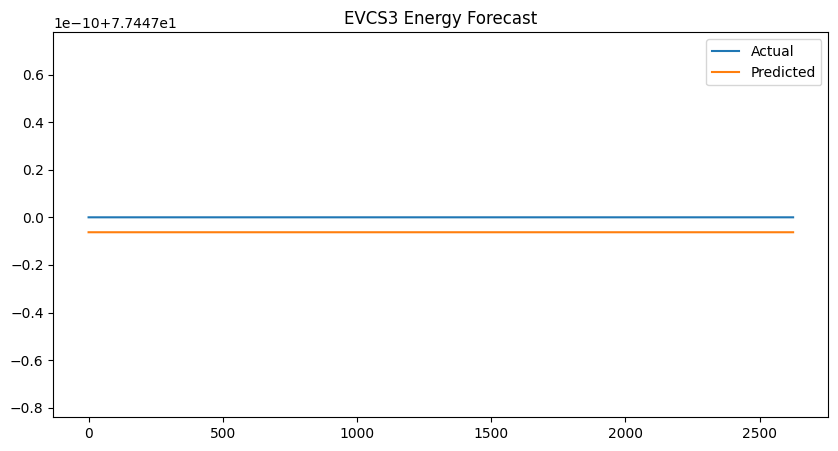

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_true, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("EVCS3 Energy Forecast")
plt.savefig("forecast.png", dpi=300, bbox_inches="tight")
plt.show()


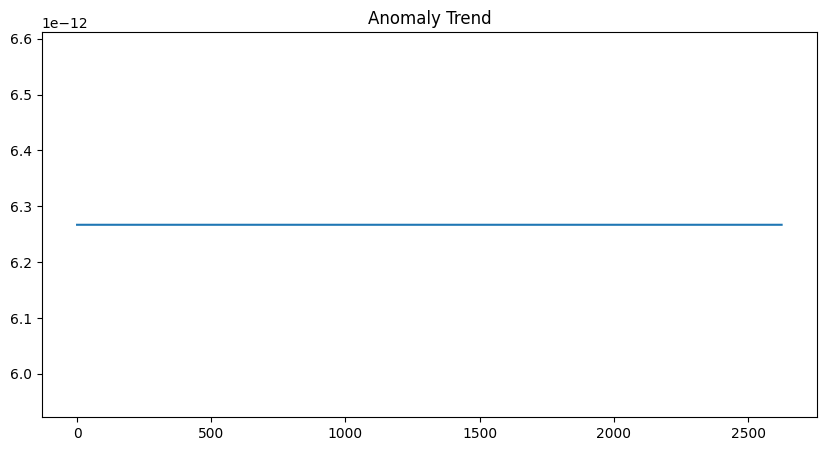

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(results["Rolling_Residual"])
plt.title("Anomaly Trend")
plt.savefig("anomaly.png", dpi=300, bbox_inches="tight")
plt.show()

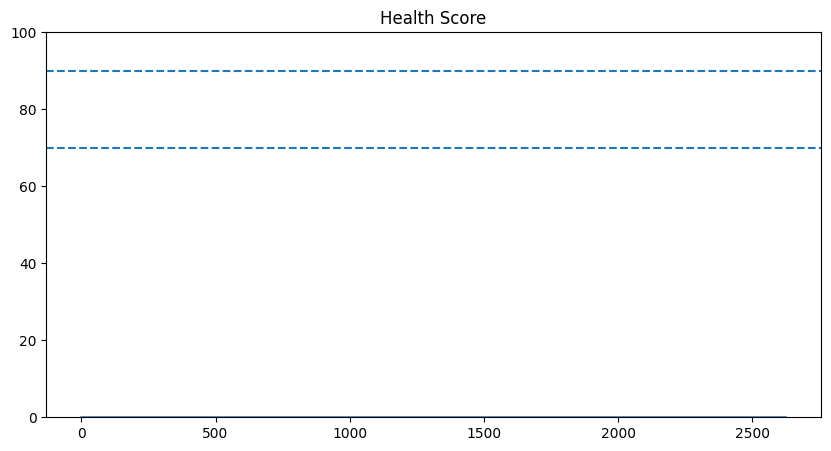

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(results["Health_Score"])

plt.axhline(90, linestyle="--")
plt.axhline(70, linestyle="--")

plt.ylim(0,100)

plt.title("Health Score")
plt.savefig("health.png", dpi=300, bbox_inches="tight")
plt.show()

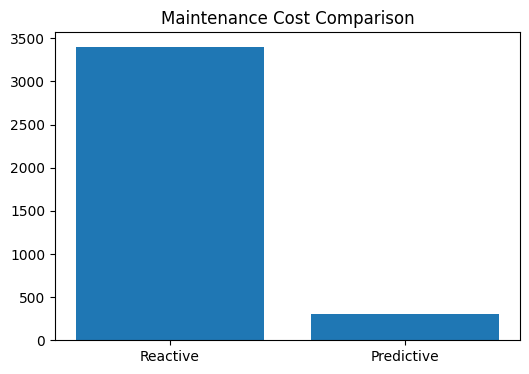

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(
    ["Reactive", "Predictive"],
    [3400, 300]
)

plt.title("Maintenance Cost Comparison")

plt.savefig("cost.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
print("Average Health Score:", round(results["Health_Score"].mean(), 1))

print("High Risk Chargers:",
      (results["Risk_Level"] == "High").sum())

print("Forecast Accuracy (R²):",
      round(results_df["R2"].mean(), 2))

print("Estimated Annual Savings:",
      round(estimated_savings, 0))

Average Health Score: 0.0
High Risk Chargers: 2626
Forecast Accuracy (R²): 0.4
Estimated Annual Savings: 8140600


In [ ]:
merged_df.to_dict(orient="records")

[{'EVCS': 'EVCS1',
  'R2': 0.3915781152989616,
  'MAE': 48.1574165003811,
  'RMSE': 61.443973224160516,
  'Average Power (kW)': 88.1783249249837},
 {'EVCS': 'EVCS2',
  'R2': 0.5222327488085257,
  'MAE': 63.02389410962719,
  'RMSE': 82.1722011924379,
  'Average Power (kW)': 122.81366360404435},
 {'EVCS': 'EVCS3',
  'R2': 0.6283737516544616,
  'MAE': 80.17090493894281,
  'RMSE': 103.33726776060486,
  'Average Power (kW)': 216.3221025587084},
 {'EVCS': 'EVCS4',
  'R2': 0.27023442664584196,
  'MAE': 31.98257519022992,
  'RMSE': 40.2699279306003,
  'Average Power (kW)': 71.037716555773},
 {'EVCS': 'EVCS5',
  'R2': 0.0966498188736864,
  'MAE': 20.539297592845067,
  'RMSE': 24.965249880659506,
  'Average Power (kW)': 34.40783086105675},
 {'EVCS': 'EVCS6',
  'R2': 0.5306380571485112,
  'MAE': 72.23638857008969,
  'RMSE': 93.96458744354796,
  'Average Power (kW)': 194.54423151174169},
 {'EVCS': 'Charging loda of EVCSs (kW)',
  'R2': 0.3915781152989616,
  'MAE': 48.1574165003811,
  'RMSE': 61.44

In [ ]:
import pandas as pd
import os

# Define the paths we expect
file_paths = [
    "/content/EVCSs.csv",
    "/content/EVCSs_0.csv",
    "/content/EVCSs (1).csv"
]

# Filter to only include files that actually exist on disk
existing_files = [f for f in file_paths if os.path.exists(f)]

if not existing_files:
    print("Error: None of the required CSV files were found in /content/. Please re-upload them.")
else:
    df_list = [pd.read_csv(f) for f in existing_files]
    df = pd.concat(df_list, ignore_index=True)
    evcs_columns = [col for col in df.columns if "EVCS" in col]
    print(f"Loaded {len(existing_files)} files.")
    print("Found EVCS columns:", evcs_columns)

Loaded 3 files.
Found EVCS columns: ['EVCS1', 'EVCS2', 'EVCS3', 'EVCS4', 'EVCS5', 'EVCS6', 'Charging loda of EVCSs (kW)']


In [ ]:
forecast_dict = {}

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

WINDOW = 24  # previous 24 hours

forecast_dict = {}

for evcs in evcs_columns:

    print(f"Processing {evcs}...")

    series = pd.to_numeric(df[evcs], errors="coerce").dropna()

    values = series.values

    X, y = [], []

    for i in range(WINDOW, len(values)):
        X.append(values[i-WINDOW:i])
        y.append(values[i])

    X = np.array(X)
    y = np.array(y)

    split = int(len(X) * 0.8)

    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    forecast_dict[evcs] = {
        "actual": y_test,
        "predicted": y_pred,
        "r2": r2_score(y_test, y_pred)
    }

print("Done!")

Processing EVCS1...
Processing EVCS2...
Processing EVCS3...
Processing EVCS4...
Processing EVCS5...
Processing EVCS6...
Processing Charging loda of EVCSs (kW)...
Done!


In [ ]:
for evcs in forecast_dict:

    print(
        evcs,
        forecast_dict[evcs]["predicted"][:5]
    )

EVCS1 [ 0.558292    2.28789    14.58741314 41.76339843 36.88186814]
EVCS2 [ 9.42001571 21.07234029 25.27964657 41.50347457 59.38951343]
EVCS3 [28.037216   25.64239829 34.74470457 52.24259971 89.327934  ]
EVCS4 [ 13.574055    21.46791943  18.27384529  60.292346   102.21991   ]
EVCS5 [28.672699  6.396434  1.024197  1.410932  7.615057]
EVCS6 [ 37.05926829  14.493241    53.212294    49.17307343 109.0115    ]
Charging loda of EVCSs (kW) [ 5.85921629 99.28951229 52.68549657 40.777906   42.956969  ]


In [ ]:
for evcs in forecast_dict:

    plt.figure(figsize=(10, 5))

    plt.plot(
        forecast_dict[evcs]["actual"],
        label="Actual"
    )

    plt.plot(
        forecast_dict[evcs]["predicted"],
        label="Predicted"
    )

    plt.title(
        f"{evcs} Energy Forecast"
    )

    plt.xlabel("Time")

    plt.ylabel("Power (kW)")

    plt.legend()

    plt.grid(True)

    plt.savefig(
        f"{evcs}_forecast.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

print("All forecast charts saved.")

All forecast charts saved.


In [ ]:
import json

dashboard_data = {}

for evcs in forecast_dict:

    actual = forecast_dict[evcs]["actual"][:50]
    predicted = forecast_dict[evcs]["predicted"][:50]

    dashboard_data[evcs] = [
        {
            "time": f"T{i+1}",
            "actual": float(actual[i]),
            "predicted": float(predicted[i])
        }
        for i in range(len(actual))
    ]

with open("dashboard_data.json", "w") as f:
    json.dump(dashboard_data, f)

print("Saved dashboard_data.json")

Saved dashboard_data.json
